# `01_pontual.ipynb` — Erro pontual no test set

**Etapa 5 — Avaliação · notebook 1 de 4**

## Objetivo

Medir o **erro pontual** (RMSE e MAE) da GAIN e dos 7 baselines no **test set**
(2024–2025), decomposto **por variável** e **por estação**, e testar estatisticamente
(Wilcoxon pareado) se a GAIN supera o melhor baseline.

> **Pergunta:** a GAIN supera os baselines em erro pontual no test? A diferença é significativa?

## Protocolo (idêntico ao das Etapas 3 e 4 — pré-condição de comparabilidade)

- Mesma máscara artificial `B = generate_artificial_mask(mask_real_test, miss_rate=0.20, seed)`
  para **todos os métodos**, com as **mesmas seeds `[42, 7, 2026]`** (memória da Etapa 3).
- Erro medido **apenas nas células escondidas** `(M=1, B=0)`, **após inversão** para a
  escala física (`clip[-1,1] → MinMax⁻¹ → Box-Cox/Yeo-Johnson⁻¹`).
- **Agregação canônica** (a mesma da Etapa 3): RMSE/MAE calculados **por seed**, depois
  **média ± desvio** entre as 3 seeds. Métrica primária de ranking = **RMSE_norm**
  (espaço normalizado `[-1,1]`, comparável entre variáveis); RMSE em escala física
  reportada em paralelo para interpretação.
- Reutiliza `baseline_utils.avaliar_baseline` para a GAIN; para os 7 baselines,
  **carrega as métricas por seed já calculadas no test na Etapa 3**
  (`Code/4 - Baseline/tabelas/baselines_{simples,ml}.csv`) e as predições persistidas
  (`Data/BaselineResults/`) — sem reexecutar imputadores (decisão do `resumo.md` da Etapa 3, §6).

### Adaptações de caminho (convenção real do projeto)

O plano (`Pipeline/05_Evaluation/01_pontual.md`) cita caminhos `Data/Pipeline/…`; os
artefatos reais vivem em `Data/GoldData/`, `Data/ProcessedData/`, `Data/BaselineResults/`
e `Code/5 - GAIN/checkpoints/`. Saídas:

| Artefato | Destino |
|---|---|
| Predições da GAIN no test | `Data/EvalResults/predictions_gain.parquet` |
| RMSE/MAE por variável | `Code/6 - Evaluation/tabelas/pontual_por_variavel.csv` |
| RMSE por estação | `Code/6 - Evaluation/tabelas/pontual_por_estacao.csv` |
| Wilcoxon GAIN × melhor baseline | `Code/6 - Evaluation/tabelas/wilcoxon_gain_vs_baseline.csv` |
| Figuras | `Data/Figures/05_Evaluation/` |

> **Coliformes Termotolerantes** tem 0 observações no test (gap conhecido desde a Etapa 2):
> não gera célula avaliável → **10 variáveis** avaliadas, não 11.

In [1]:
import sys, json
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import wilcoxon

# --- Raízes do projeto (notebook em Code/6 - Evaluation/) ---
ROOT = Path.cwd()
while not (ROOT / "Data").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent

CODE = ROOT / "Code"
sys.path.insert(0, str(CODE / "3 - Preprocessing"))   # mask_utils
sys.path.insert(0, str(CODE / "4 - Baseline"))        # baseline_utils
sys.path.insert(0, str(CODE / "5 - GAIN"))            # gain

import gain
import baseline_utils as bu
from mask_utils import generate_artificial_mask

# --- Caminhos ---
SPLIT_DIR = ROOT / "Data/GoldData/Splited"
MASK_DIR  = ROOT / "Data/GoldData/Masked"
PROC_DIR  = ROOT / "Data/ProcessedData"
BASE_DIR  = ROOT / "Data/BaselineResults"
BASE_TAB  = CODE / "4 - Baseline/tabelas"
CKPT      = CODE / "5 - GAIN/checkpoints/gain_best.pt"

OUT_PRED = ROOT / "Data/EvalResults/predictions_gain.parquet"
OUT_TAB  = CODE / "6 - Evaluation/tabelas"
OUT_FIG  = ROOT / "Data/Figures/05_Evaluation"
for d in (OUT_PRED.parent, OUT_TAB, OUT_FIG):
    d.mkdir(parents=True, exist_ok=True)

SEEDS = [42, 7, 2026]
MISS_RATE = 0.20

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.width", 170)

# --- Dados do test ---
df_test        = pd.read_parquet(SPLIT_DIR / "test.parquet")
mask_real_test = pd.read_parquet(MASK_DIR / "mask_real_test.parquet")
scalers          = joblib.load(PROC_DIR / "scalers.pkl")
with open(PROC_DIR / "transform_params.json", encoding="utf-8") as f:
    transform_params = json.load(f)

# --- Modelo GAIN (checkpoint local gerado na Etapa 4 — confiável; weights_only=False
#     necessário porque o .pt guarda hp/vars/context_cols junto dos tensores) ---
ck = torch.load(CKPT, map_location="cpu", weights_only=False)
VARS         = ck["vars"]
CONTEXT_COLS = ck["context_cols"]
G = gain.Generator(len(VARS), len(CONTEXT_COLS), ck["hp"]["hidden"])
G.load_state_dict(ck["G_state"]); G.eval()

ctx_test = torch.tensor(df_test[CONTEXT_COLS].to_numpy(dtype=np.float32))

print(f"test: {df_test.shape[0]} coletas | {len(VARS)} variáveis-alvo | {len(CONTEXT_COLS)} de contexto")
print(f"GAIN cfg: {ck['hp']}")
print("observações por variável no test (soma da máscara real):")
print(mask_real_test[VARS].sum().to_string())

test: 90 coletas | 11 variáveis-alvo | 23 de contexto
GAIN cfg: {'hint_rate': 0.9, 'alpha': 10.0, 'beta': 10.0, 'batch_size': 128, 'hidden': [128, 128], 'lr_g': 0.001, 'lr_d': 0.001, 'n_iter': 5000}
observações por variável no test (soma da máscara real):
DBO                           78
OD                            74
Nitrato                       73
Nitrogênio Amoniacal Total    77
Fósforo Total                 60
Condutividade                 72
pH                            79
Turbidez                      70
Temperatura da Água           76
Sólidos Suspensos Totais      16
Coliformes Termotolerantes     0


## 3. Aplicar a GAIN no test set

`predict_gain` segue o contrato de `baseline_utils.avaliar_baseline`: recebe `X_obs`
(normalizada, `NaN` nas células escondidas), imputa com `gain.impute(G, x_obs, m_obs, ctx_test)`
e devolve a matriz completa normalizada. Rodamos as 3 seeds → predições da GAIN em escala
original (salvas) + métricas por seed (RMSE/MAE físico e RMSE_norm).

In [2]:
def predict_gain(X_obs, seed=None):
    m_obs = torch.tensor(X_obs.notna().to_numpy(dtype=np.float32))
    x_obs = torch.tensor(X_obs.fillna(0.0).to_numpy(dtype=np.float32))
    x_imp = gain.impute(G, x_obs, m_obs, ctx_test)
    return pd.DataFrame(x_imp.numpy(), columns=VARS, index=X_obs.index)

met_gain, pred_gain = bu.avaliar_baseline(
    "gain", predict_gain, df_test, mask_real_test,
    VARS, scalers, transform_params, seeds=SEEDS, miss_rate=MISS_RATE,
    generate_artificial_mask=generate_artificial_mask)

pred_gain.to_parquet(OUT_PRED, index=False)
print(f"predições da GAIN salvas: {OUT_PRED.relative_to(ROOT)}  ({pred_gain.shape[0]} linhas)")
print(f"GAIN — RMSE_norm médio no test (10 variáveis × 3 seeds): {met_gain['RMSE_norm'].mean():.4f}")
met_gain.groupby('variavel', sort=False)[['RMSE','MAE','RMSE_norm','n_avaliado']].mean().round(4)

predições da GAIN salvas: Data\EvalResults\predictions_gain.parquet  (270 linhas)
GAIN — RMSE_norm médio no test (10 variáveis × 3 seeds): 0.3117


,RMSE,MAE,RMSE_norm,n_avaliado
variavel,,,,
DBO,9.1673,6.0161,0.2390,14.3333
OD,3.0680,2.2201,0.3102,12.3333
Nitrato,0.1778,0.1130,0.6587,14.3333
Nitrogênio Amoniacal Total,3.0530,2.0968,0.4497,13.3333
Fósforo Total,108.7871,33.9738,0.1573,10.6667
Condutividade,7981.0003,6019.3708,0.2487,13.6667
pH,0.5161,0.3953,0.2294,17.6667
Turbidez,134.2241,47.7505,0.2294,18.0000
Temperatura da Água,3.3061,2.3401,0.3306,15.6667


## 4. Reunir métricas por seed de todos os 8 métodos

As métricas **por seed** dos 7 baselines no test já foram calculadas na Etapa 3 (sob este
mesmo protocolo) e persistidas em `baselines_simples.csv` (4 métodos triviais) e
`baselines_ml.csv` (KNN, MICE, MissForest). Concatenamos com `met_gain` → base única
`metodo × variavel × seed`, **bit a bit consistente** com as etapas anteriores. Também
carregamos as **predições em escala original** (`Data/BaselineResults/` + a GAIN recém-salva)
para as análises célula a célula (estação e Wilcoxon) das seções 6–7.

In [3]:
BASELINES = ["knn", "mice", "missforest", "media_estacao",
             "media_global", "mediana_global", "ffill_estacao"]
METODOS = ["gain"] + BASELINES

# --- Métricas por seed (metodo, variavel, seed, RMSE, MAE, RMSE_norm, ...) ---
cols_met = ["metodo", "variavel", "seed", "n_avaliado", "RMSE", "MAE", "RMSE_norm", "MAE_norm"]
met_base = pd.concat([
    pd.read_csv(BASE_TAB / "baselines_simples.csv", encoding="utf-8"),
    pd.read_csv(BASE_TAB / "baselines_ml.csv", encoding="utf-8"),
], ignore_index=True)
met_todos = pd.concat([met_gain[cols_met], met_base[cols_met]], ignore_index=True)
assert set(met_todos["metodo"].unique()) == set(METODOS)
print(f"métricas por seed: {met_todos.shape[0]} linhas "
      f"(esperado 8 métodos × 10 variáveis × 3 seeds = 240): {8*10*3}")

# --- Predições em escala original, por método (para seções 6–7) ---
preds = {"gain": pred_gain}
for nome in BASELINES:
    preds[nome] = pd.read_parquet(BASE_DIR / f"predictions_{nome}.parquet")

# Verdade em escala original + estação (alinhadas por posição ao test)
X_true_orig = bu.desnormalizar(df_test[VARS], VARS, scalers, transform_params)
estacao_test = bu.coluna_estacao(df_test).to_numpy()
hidden = {s: (mask_real_test == 1) & (generate_artificial_mask(mask_real_test, MISS_RATE, s) == 0)
          for s in SEEDS}

def residuos_longos(nome):
    "Long df por célula escondida (metodo, variavel, seed, estacao, err, cel)."
    blocos = []
    for seed in SEEDS:
        bloco = preds[nome][preds[nome]["seed"] == seed].reset_index(drop=True)
        assert len(bloco) == len(df_test)
        h = hidden[seed].reset_index(drop=True)
        for var in VARS:
            idx = h[var].to_numpy(dtype=bool)
            if idx.sum() == 0:
                continue
            err = bloco[var].to_numpy()[idx] - X_true_orig[var].to_numpy()[idx]
            blocos.append(pd.DataFrame({
                "metodo": nome, "variavel": var, "seed": seed,
                "estacao": estacao_test[idx], "err": err, "cel": np.where(idx)[0]}))
    return pd.concat(blocos, ignore_index=True)

longo = pd.concat([residuos_longos(m) for m in METODOS], ignore_index=True)
VARS_AVAL = [v for v in VARS if v in longo["variavel"].unique()]
print(f"variáveis avaliáveis: {len(VARS_AVAL)}  (Coliformes fora — sem obs. no test)")

métricas por seed: 240 linhas (esperado 8 métodos × 10 variáveis × 3 seeds = 240): 240


variáveis avaliáveis: 10  (Coliformes fora — sem obs. no test)


## 5. RMSE e MAE por variável (média ± desvio sobre 3 seeds)

Métrica primária **RMSE_norm** (comparável entre variáveis); RMSE em escala física em
paralelo. `n` é o total de células avaliadas (3 seeds somadas). **Cuidado** com `n` baixo:
SST tem só 16 observações no test.

In [4]:
agg = (met_todos.groupby(["metodo", "variavel"], sort=False)
       .agg(RMSE_media=("RMSE", "mean"), RMSE_std=("RMSE", "std"),
            MAE_media=("MAE", "mean"),
            RMSE_norm_media=("RMSE_norm", "mean"), RMSE_norm_std=("RMSE_norm", "std"),
            n=("n_avaliado", "sum"))
       .reset_index())
agg.to_csv(OUT_TAB / "pontual_por_variavel.csv", index=False, encoding="utf-8")
print(f"salvo: {(OUT_TAB / 'pontual_por_variavel.csv').name}  ({len(agg)} linhas)")

# Tabela larga RMSE_norm (métrica primária) por variável × método, GAIN na 1ª coluna
larga_norm = (agg.pivot(index="variavel", columns="metodo", values="RMSE_norm_media")
              .reindex(index=VARS_AVAL, columns=METODOS))
n_por_var = agg.groupby("variavel")["n"].first().reindex(VARS_AVAL).astype(int)
larga_norm.insert(0, "n", n_por_var)
print("\nRMSE_norm (média 3 seeds) por variável × método — menor é melhor:")
larga_norm.round(3)

salvo: pontual_por_variavel.csv  (80 linhas)

RMSE_norm (média 3 seeds) por variável × método — menor é melhor:


metodo,n,gain,knn,mice,missforest,media_estacao,media_global,mediana_global,ffill_estacao
variavel,,,,,,,,,
DBO,43,0.239,0.209,0.280,0.249,0.260,0.272,0.273,0.224
OD,37,0.310,0.342,0.256,0.338,0.379,0.370,0.360,0.335
Nitrato,43,0.659,0.659,0.626,0.894,0.642,0.619,0.666,0.802
Nitrogênio Amoniacal Total,40,0.450,0.476,0.783,0.464,0.531,0.532,0.545,0.636
Fósforo Total,32,0.157,0.169,0.190,0.162,0.199,0.191,0.179,0.210
Condutividade,41,0.249,0.311,0.211,0.245,0.318,0.493,0.532,0.459
pH,53,0.229,0.220,0.276,0.198,0.288,0.295,0.296,0.377
Turbidez,54,0.229,0.223,0.173,0.179,0.238,0.324,0.327,0.191
Temperatura da Água,47,0.331,0.279,0.225,0.304,0.351,0.346,0.368,0.355


### RMSE na escala física (interpretável por variável)

In [5]:
larga_orig = (agg.pivot(index="variavel", columns="metodo", values="RMSE_media")
              .reindex(index=VARS_AVAL, columns=METODOS))
larga_orig.round(2)

metodo,gain,knn,mice,missforest,media_estacao,media_global,mediana_global,ffill_estacao
variavel,,,,,,,,
DBO,9.17,8.74,13.06,9.57,10.59,10.76,10.58,6.17
OD,3.07,3.59,2.66,3.08,4.06,4.02,3.93,3.68
Nitrato,0.18,0.20,0.16,0.22,0.16,0.16,0.17,0.14
Nitrogênio Amoniacal Total,3.05,2.74,16.48,2.72,3.05,2.77,2.86,4.07
Fósforo Total,108.79,108.82,108.89,108.79,108.86,108.92,108.87,108.86
Condutividade,7981.00,9971.23,6690.25,7870.32,10200.51,15836.54,17085.61,14745.07
pH,0.52,0.50,0.62,0.45,0.65,0.66,0.67,0.85
Turbidez,134.22,141.37,64.29,131.98,145.02,153.41,153.65,143.82
Temperatura da Água,3.31,2.79,2.25,3.04,3.51,3.46,3.68,3.55


### Agregado global e figura

**RMSE_norm agregado** = média sobre as 10 variáveis × 3 seeds (mesma definição da Etapa 3,
onde o KNN marcou 0,313 e foi o baseline a bater). Na figura, barras de RMSE_norm por
variável e método (comparável entre variáveis), GAIN destacada; barra de erro = desvio entre seeds.

RMSE_norm agregado no test (10 variáveis × 3 seeds):
  gain             0.3117   <-- GAIN
  knn              0.3127
  mice             0.3328
  missforest       0.3469
  media_estacao    0.3497
  media_global     0.3762
  mediana_global   0.3850
  ffill_estacao    0.3979


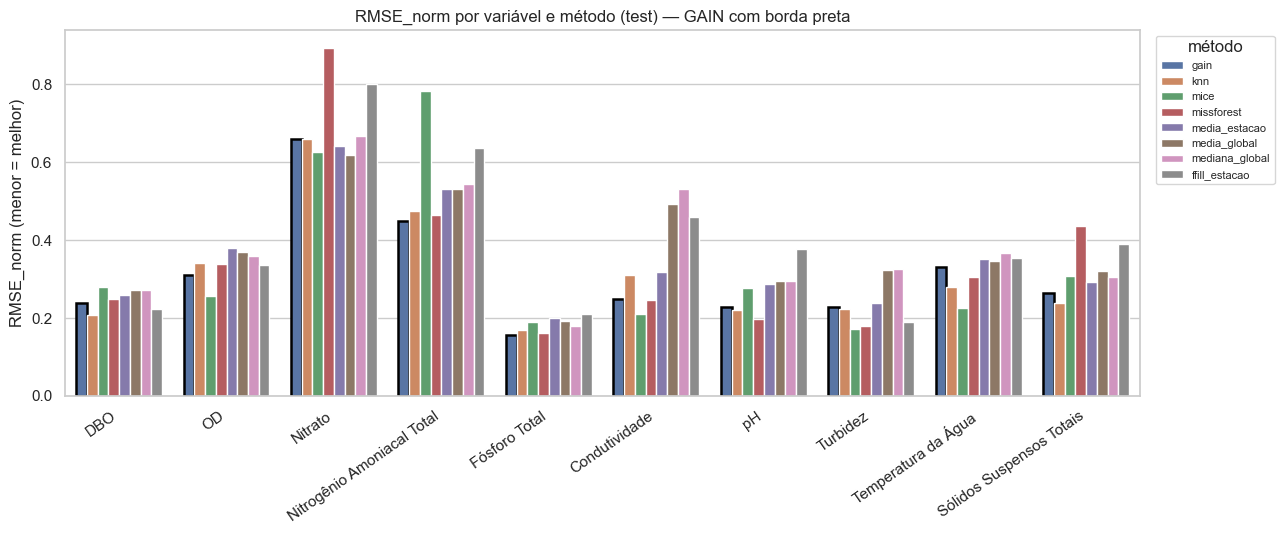

figura salva: pontual_barras.png


In [6]:
agg_global = (met_todos.groupby("metodo")["RMSE_norm"].mean()
              .reindex(METODOS).sort_values())
print("RMSE_norm agregado no test (10 variáveis × 3 seeds):")
for m, v in agg_global.items():
    print(f"  {m:16s} {v:.4f}" + ("   <-- GAIN" if m == 'gain' else ""))

fig, ax = plt.subplots(figsize=(13, 5.5))
plot_df = (met_todos.groupby(["variavel", "metodo"])["RMSE_norm"].mean()
           .reset_index())
plot_df["variavel"] = pd.Categorical(plot_df["variavel"], VARS_AVAL, ordered=True)
err_df = (met_todos.groupby(["variavel", "metodo"])["RMSE_norm"].std().reset_index())
sns.barplot(data=plot_df, x="variavel", y="RMSE_norm", hue="metodo",
            hue_order=METODOS, ax=ax)
for bars, met in zip(ax.containers, METODOS):
    if met == "gain":
        for b in bars:
            b.set_edgecolor("black"); b.set_linewidth(1.8)
ax.set_title("RMSE_norm por variável e método (test) — GAIN com borda preta")
ax.set_xlabel(""); ax.set_ylabel("RMSE_norm (menor = melhor)")
ax.tick_params(axis="x", rotation=35)
for lbl in ax.get_xticklabels(): lbl.set_ha("right")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8, title="método")
fig.tight_layout()
fig.savefig(OUT_FIG / "pontual_barras.png", dpi=130, bbox_inches="tight")
plt.show()
print(f"figura salva: {(OUT_FIG / 'pontual_barras.png').name}")

## 6. RMSE por estação

Para agregar **entre variáveis** numa mesma estação (unidades diferentes), padronizamos o
erro de cada célula pela escala da variável: `err_pad = |err| / RMSE_global(variável)`
(RMSE_global = RMSE da variável somando todos os métodos e células). Assim `1.0` ≈ erro
típico da variável e a média por `(método, estação)` fica comparável. Heatmap: menor = melhor.

salvo: pontual_por_estacao.csv


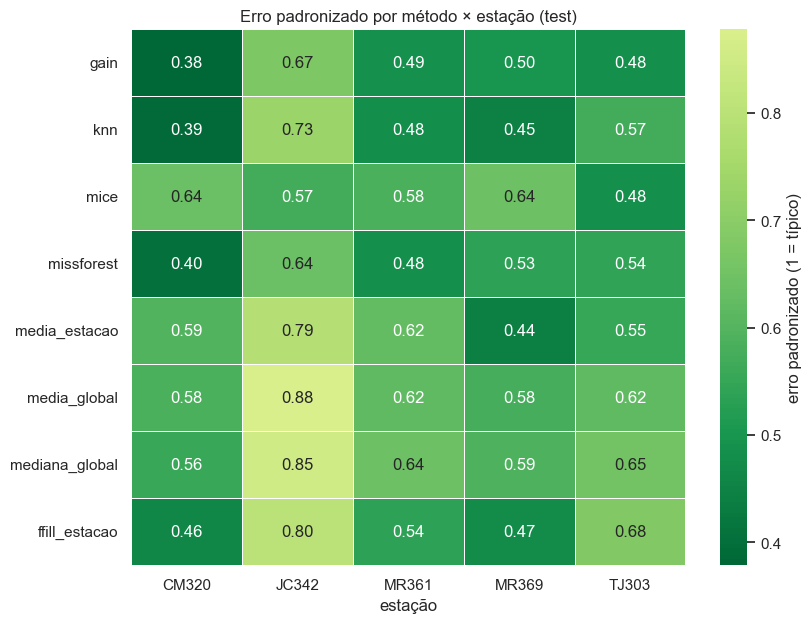

figura salva: pontual_heatmap_estacao.png


estacao,CM320,JC342,MR361,MR369,TJ303
metodo,,,,,
gain,0.379,0.673,0.490,0.497,0.482
knn,0.387,0.733,0.479,0.446,0.571
mice,0.637,0.569,0.584,0.640,0.483
missforest,0.402,0.636,0.483,0.535,0.542
media_estacao,0.594,0.789,0.624,0.442,0.550
media_global,0.584,0.878,0.621,0.576,0.620
mediana_global,0.556,0.852,0.641,0.591,0.654
ffill_estacao,0.461,0.800,0.538,0.474,0.684


In [7]:
rmse = lambda e: float(np.sqrt(np.mean(np.square(e))))
rmse_global_var = longo.groupby("variavel")["err"].transform(rmse)
longo["err_pad"] = np.abs(longo["err"]) / rmse_global_var

por_est = (longo.groupby(["metodo", "estacao"])
           .agg(err_pad=("err_pad", "mean"), n=("err", "size")).reset_index())
por_est.to_csv(OUT_TAB / "pontual_por_estacao.csv", index=False, encoding="utf-8")
print(f"salvo: {(OUT_TAB / 'pontual_por_estacao.csv').name}")

heat = por_est.pivot(index="metodo", columns="estacao", values="err_pad").reindex(METODOS)
fig, ax = plt.subplots(figsize=(1.1 * heat.shape[1] + 3, 0.55 * len(METODOS) + 2))
sns.heatmap(heat, annot=True, fmt=".2f", cmap="RdYlGn_r", center=1.0,
            linewidths=.5, cbar_kws={"label": "erro padronizado (1 = típico)"}, ax=ax)
ax.set_title("Erro padronizado por método × estação (test)")
ax.set_xlabel("estação"); ax.set_ylabel("")
fig.tight_layout()
fig.savefig(OUT_FIG / "pontual_heatmap_estacao.png", dpi=130, bbox_inches="tight")
plt.show()
print(f"figura salva: {(OUT_FIG / 'pontual_heatmap_estacao.png').name}")
heat.round(3)

## 7. Teste pareado de Wilcoxon — GAIN × melhor baseline

Para cada variável, o **melhor baseline** é o de menor RMSE físico médio. Comparamos os
**erros absolutos por célula** da GAIN contra esse baseline **nas mesmas células**
(pareamento por `(seed, célula)` — máscaras idênticas garantem o alinhamento). Wilcoxon
signed-rank:

- **H₀**: mesma distribuição de erros absolutos (mediana da diferença = 0).
- `p < 0.05` → diferença significativa. `delta_mediano = mediana(|e_gain| − |e_base|)`;
  **negativo favorece a GAIN**. Só testamos variáveis com **≥ 10 pares**.

In [8]:
def ae_por_celula(nome, var):
    s = longo[(longo["metodo"] == nome) & (longo["variavel"] == var)]
    return s.assign(ae=np.abs(s["err"])).set_index(["seed", "cel"])["ae"].sort_index()

rmse_med = larga_orig  # RMSE físico médio por variável × método
linhas = []
for var in VARS_AVAL:
    baselines_rmse = rmse_med.loc[var, BASELINES]
    melhor = baselines_rmse.idxmin()
    eg = ae_por_celula("gain", var); eb = ae_por_celula(melhor, var)
    comum = eg.index.intersection(eb.index); n = len(comum)
    reg = {"variavel": var, "melhor_baseline": melhor, "n_pares": n,
           "RMSE_gain": round(float(rmse_med.loc[var, "gain"]), 3),
           "RMSE_baseline": round(float(baselines_rmse.min()), 3)}
    if n >= 10:
        g = eg.loc[comum].to_numpy(); b = eb.loc[comum].to_numpy()
        reg["delta_mediano"] = float(np.median(g - b))
        if np.allclose(g - b, 0):
            reg["W"], reg["pvalue"] = np.nan, 1.0
        else:
            W, p = wilcoxon(g, b)
            reg["W"], reg["pvalue"] = float(W), float(p)
        reg["favorece"] = "GAIN" if reg["delta_mediano"] < 0 else "baseline"
        reg["signif_5pct"] = bool(reg["pvalue"] < 0.05)
    else:
        reg.update({"delta_mediano": np.nan, "W": np.nan, "pvalue": np.nan,
                    "favorece": "n<10", "signif_5pct": False})
    linhas.append(reg)

wilcox = pd.DataFrame(linhas)
wilcox.to_csv(OUT_TAB / "wilcoxon_gain_vs_baseline.csv", index=False, encoding="utf-8")
print(f"salvo: {(OUT_TAB / 'wilcoxon_gain_vs_baseline.csv').name}")
wilcox.round(4)

salvo: wilcoxon_gain_vs_baseline.csv


,variavel,melhor_baseline,n_pares,RMSE_gain,RMSE_baseline,delta_mediano,W,pvalue,favorece,signif_5pct
0,DBO,ffill_estacao,43,9.167,6.171,0.8257,400.0,0.3851,baseline,False
1,OD,mice,37,3.068,2.664,0.1825,330.0,0.7457,baseline,False
2,Nitrato,ffill_estacao,43,0.178,0.143,0.0069,428.0,0.5869,baseline,False
3,Nitrogênio Amoniacal Total,missforest,40,3.053,2.721,-0.1726,376.0,0.6559,GAIN,False
4,Fósforo Total,missforest,32,108.787,108.787,-0.0911,160.0,0.0518,GAIN,False
5,Condutividade,mice,41,7981.000,6690.251,928.6161,299.0,0.0884,baseline,False
6,pH,missforest,53,0.516,0.446,-0.0397,694.0,0.8490,GAIN,False
7,Turbidez,mice,54,134.224,64.290,0.6988,572.0,0.1421,baseline,False
8,Temperatura da Água,mice,47,3.306,2.254,0.0067,425.0,0.1413,baseline,False
9,Sólidos Suspensos Totais,knn,10,28.334,26.465,9.6768,23.0,0.6953,baseline,False


## 8. Ranking final por variável

Posição da GAIN entre os 8 métodos por **RMSE_norm médio** (1 = melhor).

In [9]:
base_norm = larga_norm.drop(columns="n")
rank = base_norm.rank(axis=1, method="min")
ranking = pd.DataFrame({
    "melhor_metodo": base_norm.idxmin(axis=1),
    "RMSE_norm_melhor": base_norm.min(axis=1).round(3),
    "RMSE_norm_gain": larga_norm["gain"].round(3),
    "posicao_gain": rank["gain"].astype(int),
    "n": larga_norm["n"],
})
n_var = len(ranking)
em1 = int((ranking["posicao_gain"] == 1).sum())
em2 = int((ranking["posicao_gain"] == 2).sum())
print(f"GAIN em 1º em {em1}/{n_var} variáveis | 2º em {em2}/{n_var} | top-2 em {em1+em2}/{n_var}")
ranking

GAIN em 1º em 2/10 variáveis | 2º em 2/10 | top-2 em 4/10


,melhor_metodo,RMSE_norm_melhor,RMSE_norm_gain,posicao_gain,n
variavel,,,,,
DBO,knn,0.209,0.239,3,43
OD,mice,0.256,0.310,2,37
Nitrato,media_global,0.619,0.659,4,43
Nitrogênio Amoniacal Total,gain,0.450,0.450,1,40
Fósforo Total,gain,0.157,0.157,1,32
Condutividade,mice,0.211,0.249,3,41
pH,missforest,0.198,0.229,3,53
Turbidez,mice,0.173,0.229,5,54
Temperatura da Água,mice,0.225,0.331,4,47


## 9. Síntese — veredicto pontual

In [10]:
sig_gain = wilcox[(wilcox["favorece"] == "GAIN") & wilcox["signif_5pct"]]
sig_base = wilcox[(wilcox["favorece"] == "baseline") & wilcox["signif_5pct"]]
gain_norm = agg_global["gain"]; melhor_base = agg_global.drop("gain").min()
melhor_base_nome = agg_global.drop("gain").idxmin()
print("VEREDICTO PONTUAL — test set")
print("=" * 62)
print(f"Variáveis avaliadas ............. {n_var}  (Coliformes sem obs. no test)")
print(f"RMSE_norm agregado — GAIN ....... {gain_norm:.4f}")
print(f"RMSE_norm agregado — melhor base  {melhor_base:.4f}  ({melhor_base_nome})")
print(f"GAIN é o melhor método em ....... {em1}/{n_var} variáveis (top-2 em {em1+em2})")
print(f"GAIN vence c/ significância ..... {len(sig_gain)} variáveis (Wilcoxon p<0.05):")
for _, r in sig_gain.iterrows():
    print(f"     - {r['variavel']} (vs {r['melhor_baseline']}, p={r['pvalue']:.4g})")
print(f"Baseline vence c/ significância . {len(sig_base)} variáveis:")
for _, r in sig_base.iterrows():
    print(f"     - {r['variavel']} (melhor: {r['melhor_baseline']}, p={r['pvalue']:.4g})")
print("\nCaveats: SST (n baixo) e Nitrato (censura à esquerda, r fraco na Etapa 4)")
print("são ruidosos — indicativos, não conclusivos.")

VEREDICTO PONTUAL — test set
Variáveis avaliadas ............. 10  (Coliformes sem obs. no test)
RMSE_norm agregado — GAIN ....... 0.3117
RMSE_norm agregado — melhor base  0.3127  (knn)
GAIN é o melhor método em ....... 2/10 variáveis (top-2 em 4)
GAIN vence c/ significância ..... 0 variáveis (Wilcoxon p<0.05):
Baseline vence c/ significância . 0 variáveis:

Caveats: SST (n baixo) e Nitrato (censura à esquerda, r fraco na Etapa 4)
são ruidosos — indicativos, não conclusivos.


### Leitura

O número a reter é o **RMSE_norm agregado no test** frente ao agregado do melhor baseline,
somado à contagem de vitórias por variável e à sua significância (Wilcoxon). Diferente do
**val** (onde a GAIN marcou 0,2317 vs 0,2742 do KNN), o **test** é o juiz final e não foi
usado em nenhuma decisão de treino/seleção — por isso é a medida honesta de generalização.
Variáveis com poucas células (SST) ou censura forte (Nitrato) pedem cautela.

**Próximo notebook:** `02_distribuicoes.ipynb` (Kolmogorov–Smirnov entre real e imputado).